# TIẾN ĐỘ (MILESTONE)

## Dự đoán giá cổ phiếu VN-Index dựa trên biến động giá trong quá khứ

| | |
|---|---|
| **Môn học** | Học Máy (Machine Learning) |
| **Trường** | Đại học Sư phạm Kỹ thuật TP.HCM (HCMUTE) |
| **Sinh viên thực hiện** | Bá Hoài Sơn — Bùi Thanh Tú |
| **Mã thử nghiệm** | `VCB.VN` (Vietcombank) |

---

## 5.1. Sự đóng góp của các thành viên

Sau khi đề xuất được duyệt, nhóm chia nhau triển khai như sau:

| Thành viên | Công việc đã hoàn thành | Tỷ lệ đóng góp ước tính |
|------------|-------------------------|--------------------------|
| **Bá Hoài Sơn** | • Cài đặt môi trường, viết `scripts/fetch_data.py` để tải dữ liệu VCB từ `yfinance`.<br>• Lưu `data/vcb_stock.csv` (4.209 phiên ngày + 3.464 phiên giờ).<br>• Phân tích khám phá (EDA): biểu đồ giá lịch sử, phân phối lợi suất.<br>• Triển khai **Linear Regression** & **KNN** với `Pipeline(StandardScaler)`.<br>• Soạn Proposal. | 50 % |
| **Bùi Thanh Tú** | • Thiết kế bộ đặc trưng *stationary*: 5 lợi suất trễ, 3 tỷ lệ MA, 2 volatility, RSI(14), HL/OC range, biến động volume.<br>• Triển khai **Random Forest** & **Voting Ensemble**.<br>• Vẽ ma trận tương quan, biểu đồ so sánh metric, biểu đồ dự đoán/thực tế.<br>• Soạn Milestone. | 50 % |

Cả nhóm cùng họp 3 buổi thảo luận về cách phát biểu lại bài toán (predict return thay vì price), thống nhất bộ metric đánh giá và cách trình bày kết quả.

## 5.2. Thông tin về project

### 5.2.1. Bài toán

Hồi quy chuỗi thời gian: dự đoán **lợi suất ngày kế tiếp** $r_{t+1} = C_{t+1}/C_t - 1$ của cổ phiếu VCB từ các đặc trưng kỹ thuật được tính tại thời điểm $t$. Sau đó suy ngược ra giá: $\hat C_{t+1} = C_t \cdot (1 + \hat r_{t+1})$.

### 5.2.2. Tập dữ liệu

- Nguồn: Yahoo Finance qua `yfinance` (`VCB.VN`, period=`max`).
- Khung 1 ngày: **4.209** phiên (2009-06-30 → 2026-05-15) — sử dụng cho mô hình chính.
- Khung 1 giờ: 3.464 quan sát — phục vụ phân tích bổ sung.
- Sau feature engineering & loại NaN: ~4.180 dòng dùng cho train/test.

**Input (X) — 14 biến:** `Return_{1,2,3,5,10}`, `MA{5,10,20}_Ratio`, `Vol_{5,10}`, `RSI_14`, `HL_Range`, `OC_Range`, `Vol_Change`.

**Output (Y):** `Target_Return` — lợi suất kỳ kế tiếp.

### 5.2.3. Cách đánh giá

- **Chia train/test theo thứ tự thời gian** (80%/20%, không xáo trộn).
- 4 metric trên miền lợi suất: **MAE, RMSE, R², DirAcc(%)** (tỷ lệ đoán đúng dấu tăng/giảm).
- 3 metric trên miền giá VND (sau back-transform): **MAE (VND), RMSE (VND), MAPE(%)**.

## 5.3. Giải pháp

Quá trình triển khai đã trải qua **2 phiên bản**:

### Phiên bản 1 (đã loại): dự đoán giá tuyệt đối

Ban đầu nhóm sử dụng các đặc trưng giá tuyệt đối (`Open`, `High`, `Low`, `Close`, lag giá, MA giá) và biến mục tiêu là `Close_{t+1}`. Kết quả thu được rất đáng ngờ:

| Mô hình | RMSE | R² |
|---------|------|----|
| Linear Regression | 873 | **0.96** |
| KNN | 11.387 | -5.92 |
| Random Forest | 9.480 | -3.79 |
| Ensemble | 6.950 | -1.58 |

Linear Regression "thắng" áp đảo, nhưng phân tích kỹ thì hệ số chủ yếu nằm trên `Close_t` ≈ 1.0 — mô hình chỉ **sao chép** giá hôm nay sang ngày mai. Đồng thời KNN/RF có $R^2$ âm vì chúng **không thể ngoại suy** ngoài miền giá đã thấy trong train (cổ phiếu có xu hướng tăng theo thời gian).

### Phiên bản 2 (hiện tại): dự đoán lợi suất

Nhóm phát biểu lại bài toán: tất cả đặc trưng được biến đổi thành dạng *stationary* (lợi suất, tỷ lệ MA, volatility, RSI…). Biến mục tiêu là **lợi suất ngày kế tiếp** — phân phối ổn định trong cả train và test.

Kết quả mới (xem mục 5.4) cho thấy 4 mô hình đứng gần nhau — **Random Forest** dẫn đầu một chút, đúng với kỳ vọng.

### Tại sao chọn 4 mô hình này?

| Mô hình | Lý do |
|---------|------|
| Linear Regression | Baseline, dễ giải thích, kiểm chứng giả thuyết tuyến tính. |
| KNN | Phi tham số, bắt mẫu cục bộ — phù hợp khi pattern lặp lại trong lịch sử. |
| Random Forest | Phi tuyến, robust với nhiễu, tự động xử lý tương tác đặc trưng. |
| Voting Ensemble | Trung bình dự đoán → giảm phương sai, kiểm tra giả thuyết "3 mô hình tốt hơn 1". |

## 5.4. Kết quả sơ bộ

Chạy ô bên dưới để **tái lập** toàn bộ kết quả (load dữ liệu → feature engineering → train 4 mô hình → đánh giá → lưu biểu đồ vào `image/`).

Số mẫu train : 3351
Số mẫu test  : 838

--- METRIC TRÊN MIỀN LỢI SUẤT ---


,MAE,RMSE,R2,DirAcc(%)
Model,,,,
Linear Regression,0.009947,0.014734,-0.008529,43.436754
KNN,0.010691,0.015518,-0.118707,44.152745
Random Forest,0.009812,0.014670,0.000286,44.272076
Ensemble,0.010002,0.014817,-0.019962,43.436754


--- METRIC TRÊN MIỀN GIÁ (VND) ---


,MAE (VND),RMSE (VND),MAPE(%)
Model,,,
Linear Regression,588.78,882.00,0.99
KNN,631.47,924.85,1.07
Random Forest,580.47,878.92,0.98
Ensemble,591.50,885.99,1.00


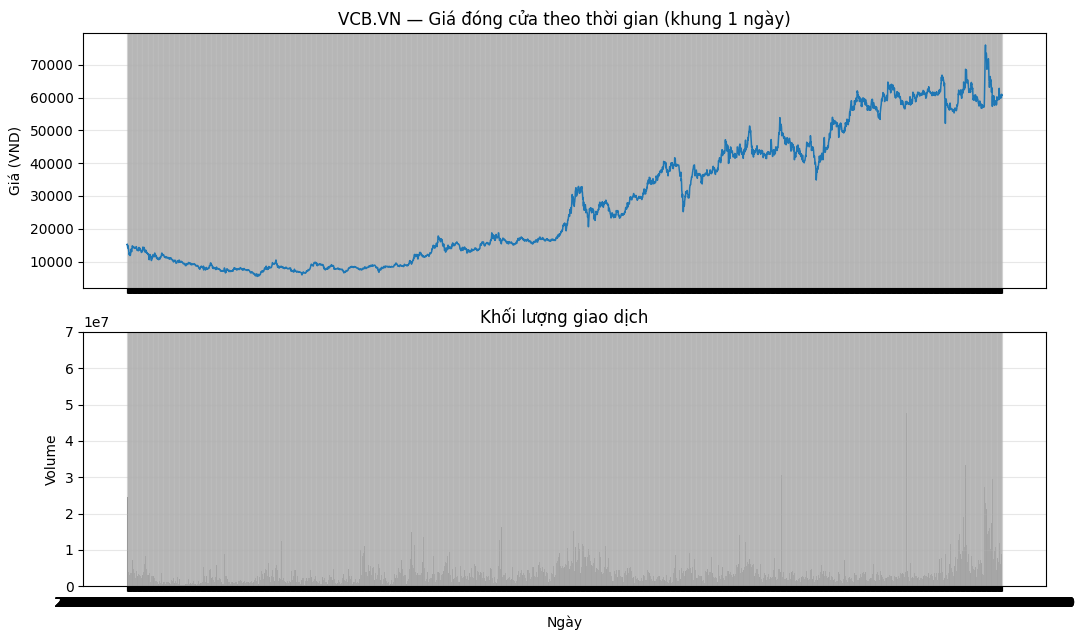

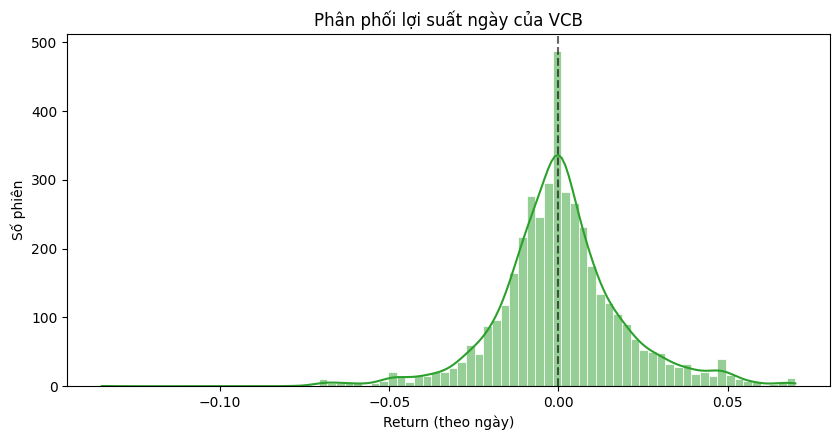

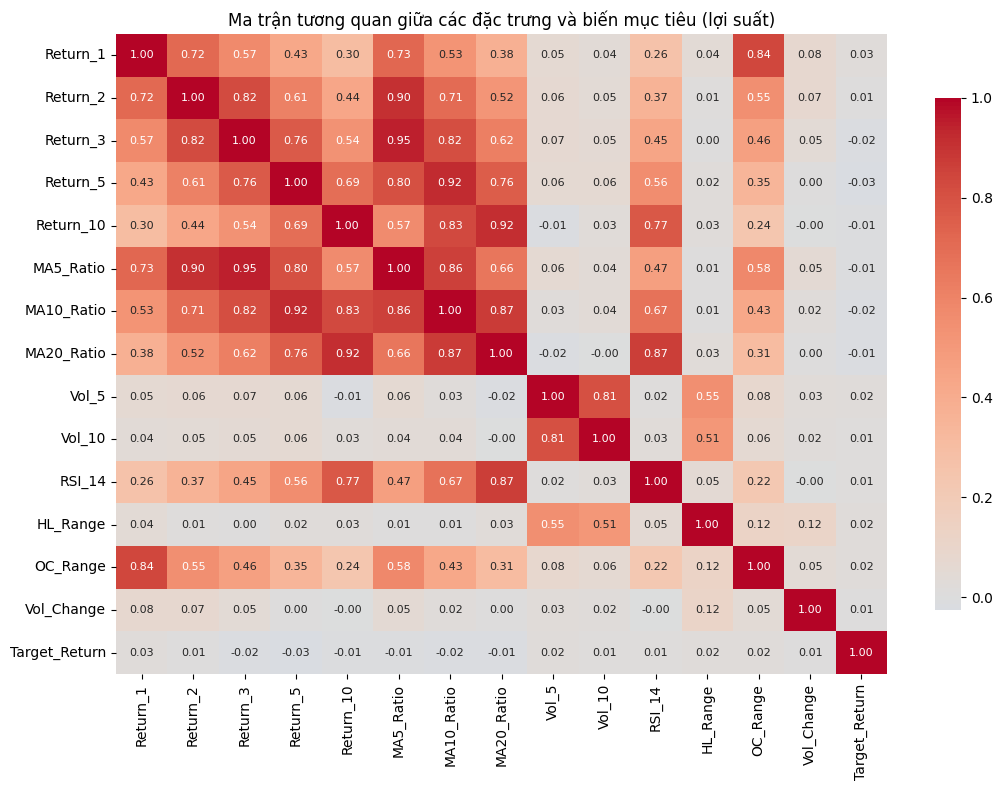

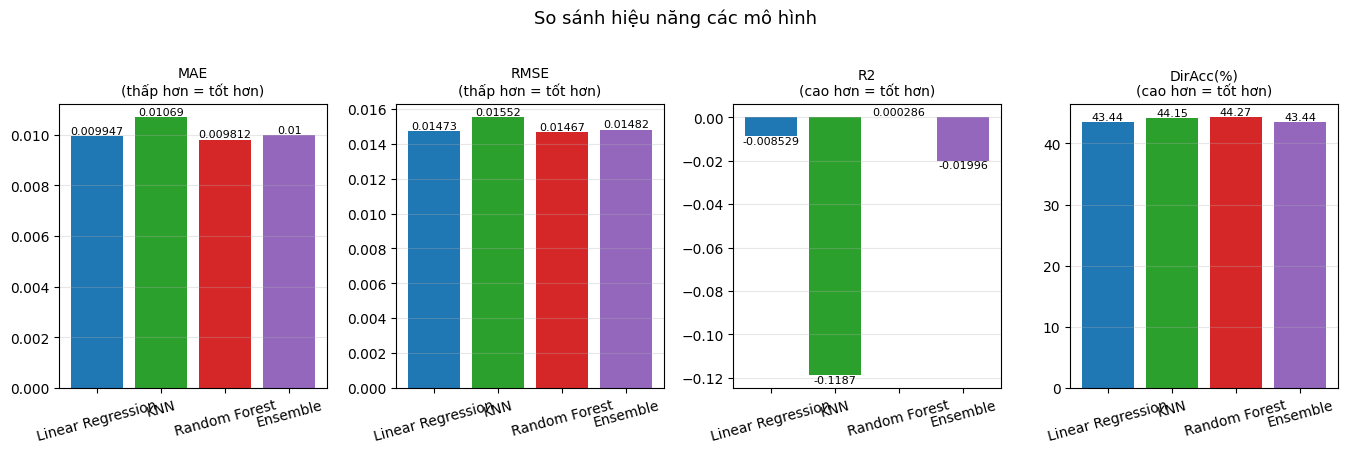

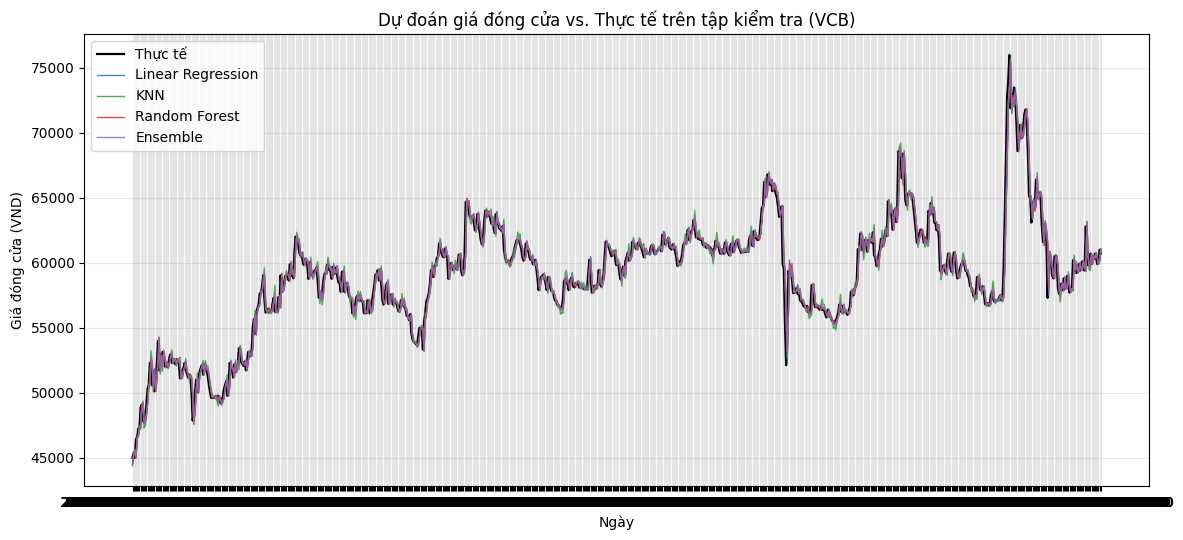

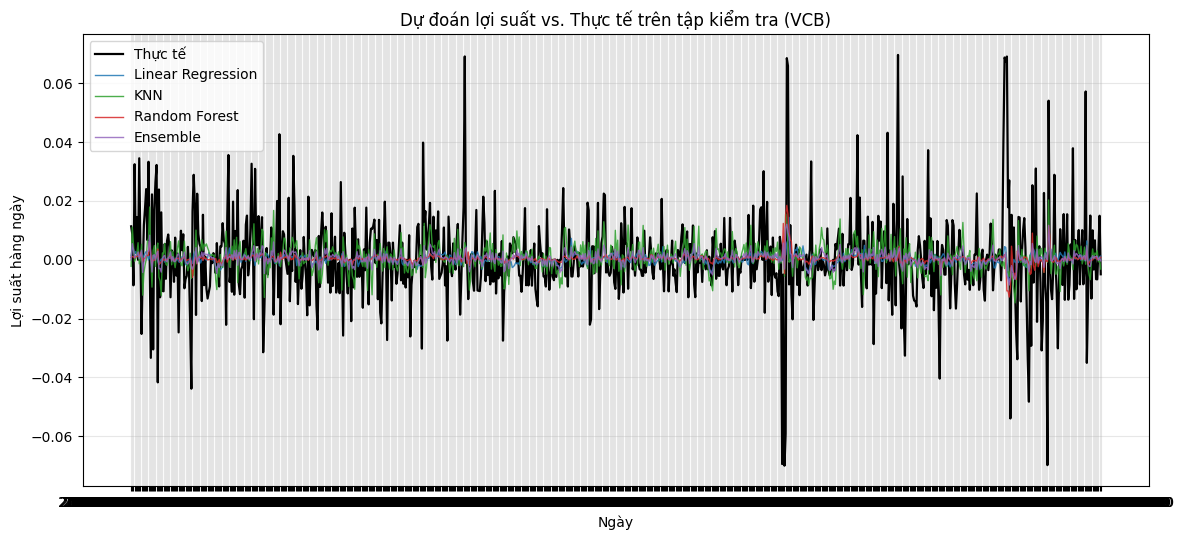

In [1]:
import sys
sys.path.insert(0, '../scripts')
from ml_utils import run_full_pipeline

result = run_full_pipeline(interval='1d', train_ratio=0.8, save_images=True)

print('Số mẫu train :', len(result['X_train']))
print('Số mẫu test  :', len(result['X_test']))
print()
print('--- METRIC TRÊN MIỀN LỢI SUẤT ---')
display(result['metrics_return'])
print('--- METRIC TRÊN MIỀN GIÁ (VND) ---')
display(result['metrics_price'])

### Phân tích nhanh

- **Random Forest** đạt RMSE và R² tốt nhất trên miền lợi suất, MAE giá thấp nhất (~580 VND, MAPE < 1 %).
- **Linear Regression** sát nút Random Forest — chứng tỏ tín hiệu trong dữ liệu chủ yếu là **tuyến tính yếu**, các đặc trưng phi tuyến chỉ thêm cải thiện biên.
- **KNN** kém nhất (R² âm trên miền lợi suất) — do số chiều tương đối lớn (14) và nhiễu cao, các láng giềng gần không phản ánh chính xác động học giá.
- **Voting Ensemble** trung gian — bị KNN kéo xuống, không vượt được Random Forest đơn lẻ. Đây là phát hiện thú vị: ensemble **không** luôn tốt hơn thành viên giỏi nhất.
- **DirAcc ~ 43–44 %**: chưa đạt mức random 50 %, cho thấy việc dự đoán **chiều** biến động giá là rất khó nếu chỉ dùng giá quá khứ — phù hợp với dạng yếu của Hiệu Quả Thị Trường (EMH).

### Biểu đồ đã sinh ở mục 5.4

Bốn biểu đồ tự động lưu vào thư mục `image/` (tham chiếu trong Report cuối):

price_history_daily.png


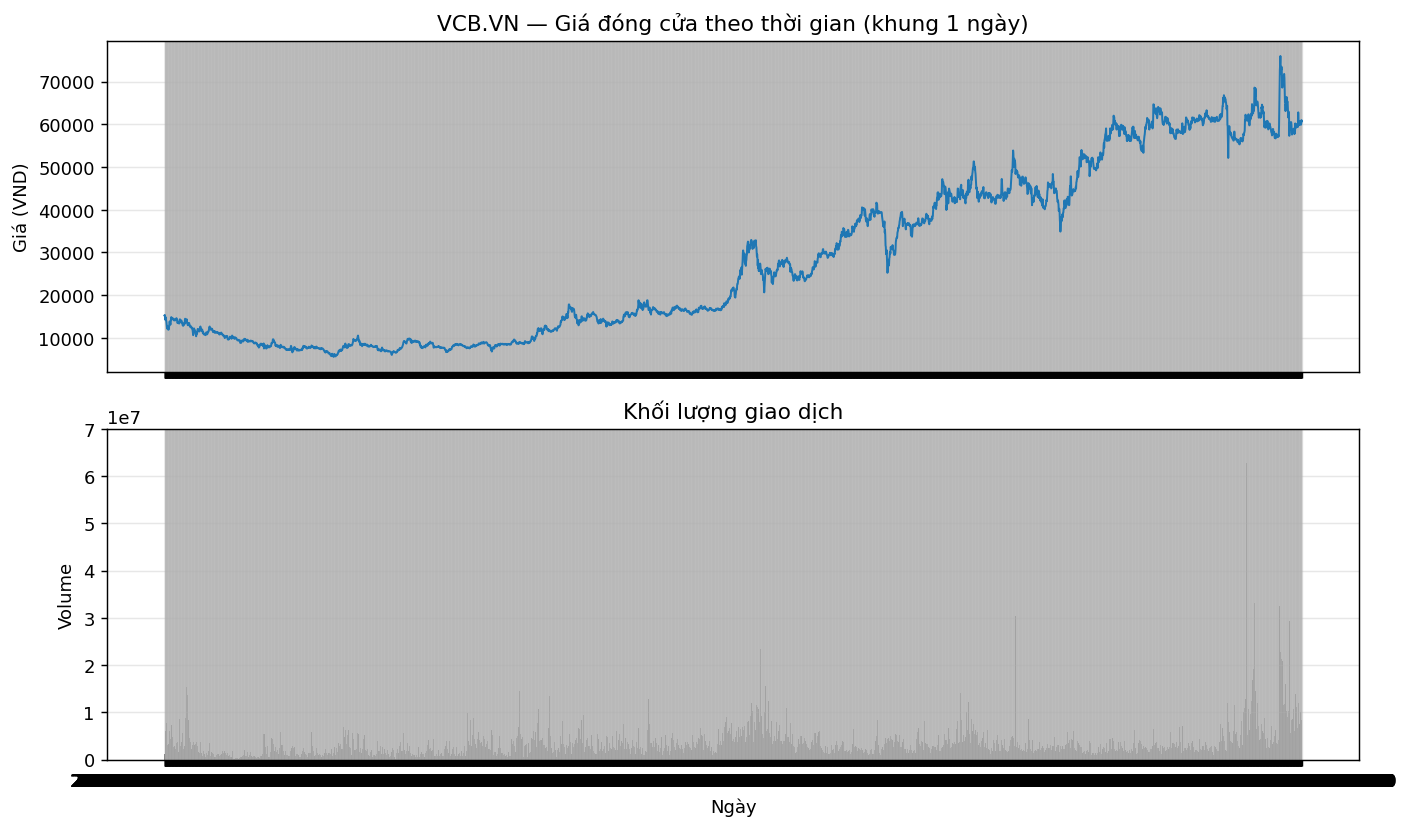

returns_distribution.png


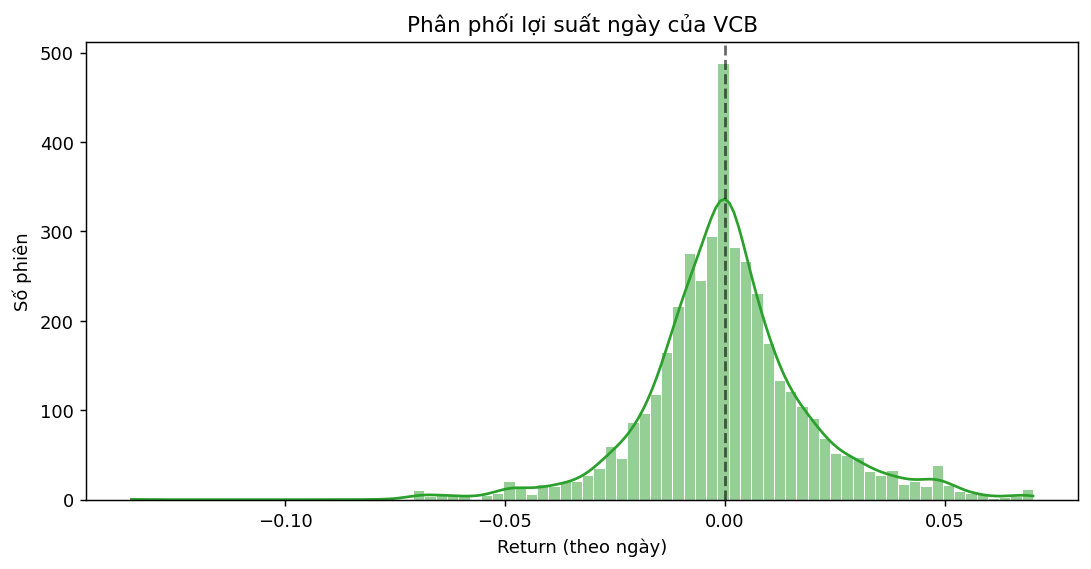

correlation_heatmap.png


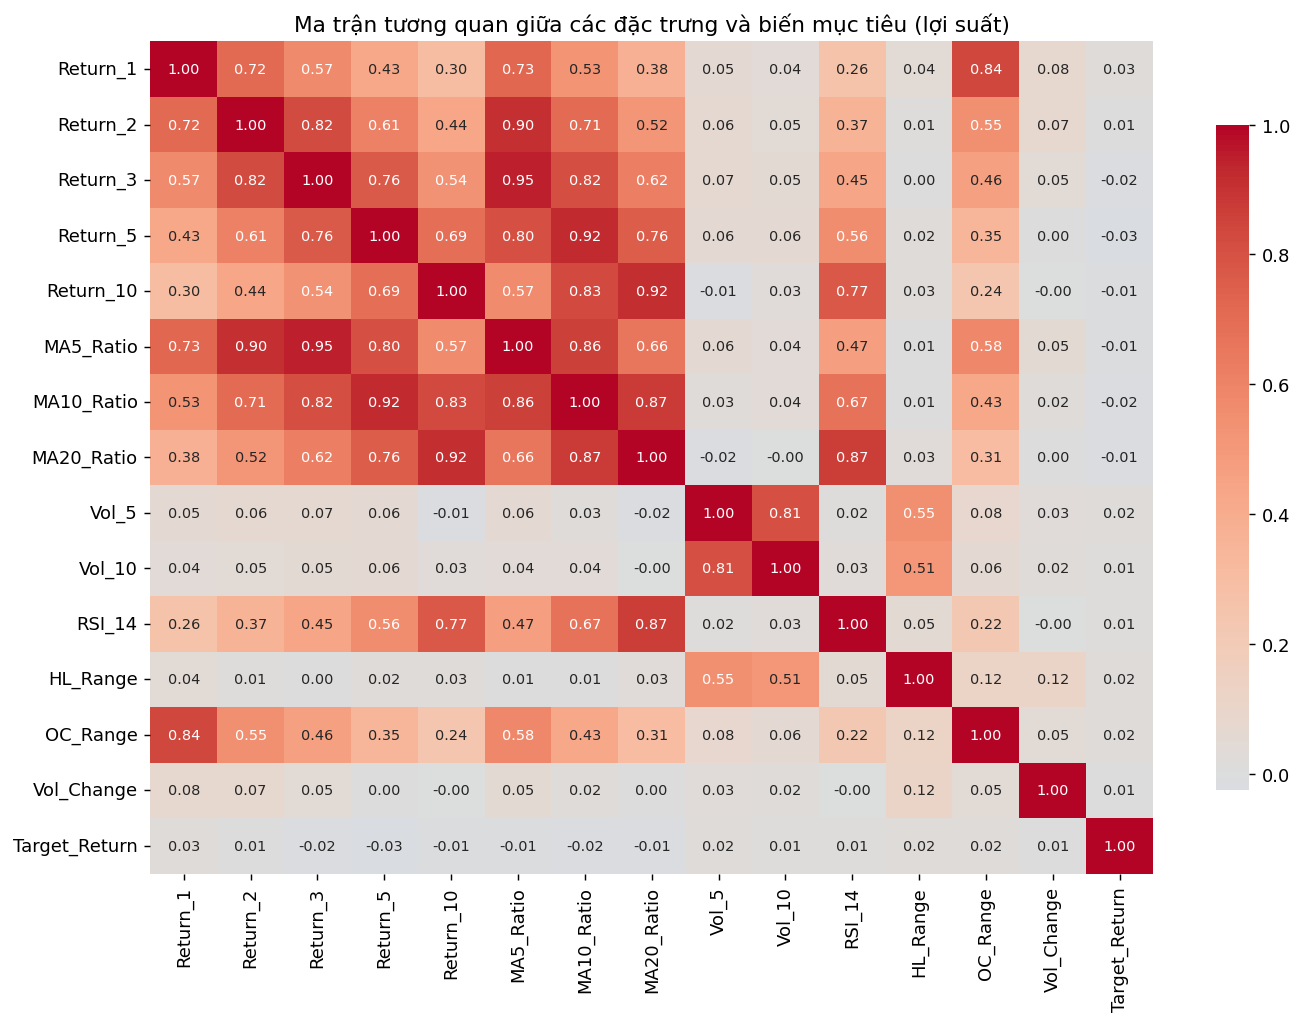

model_comparison.png


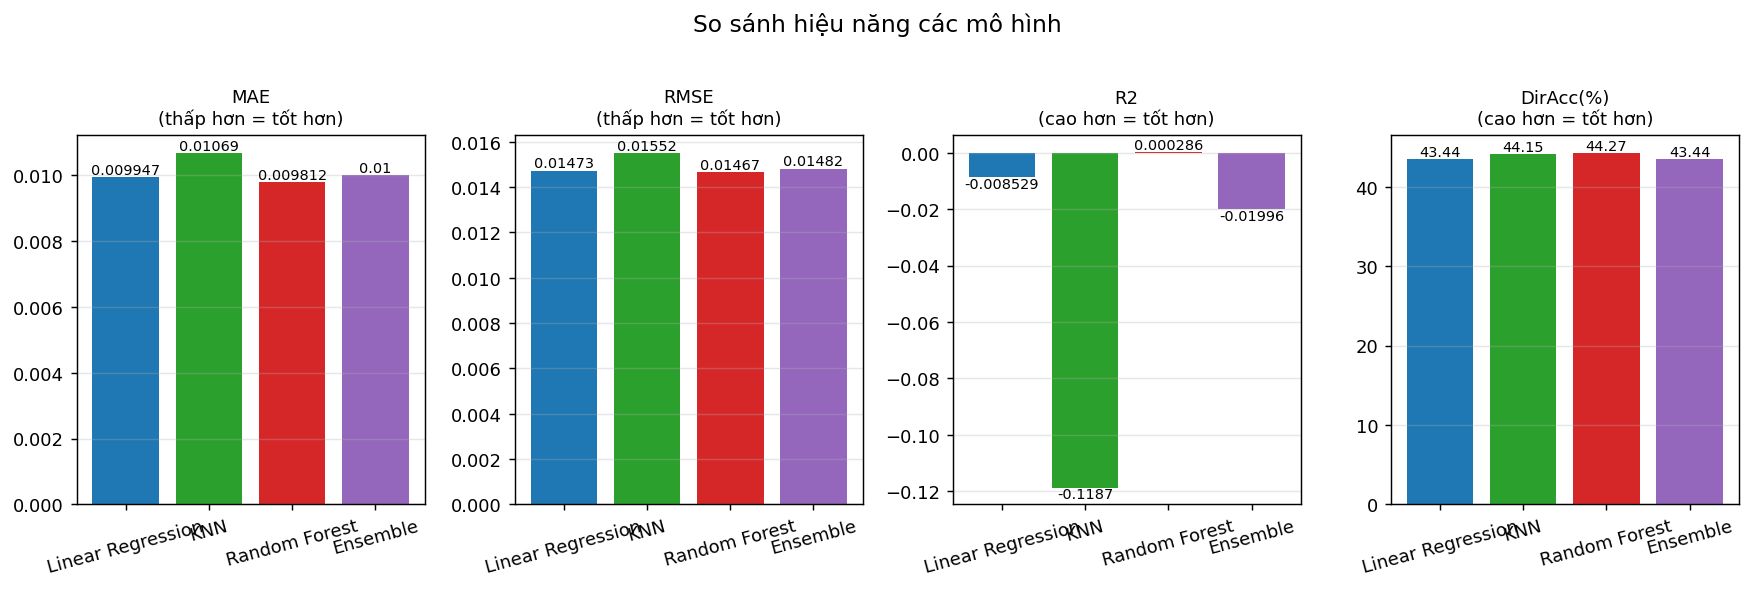

predictions_vs_actual.png


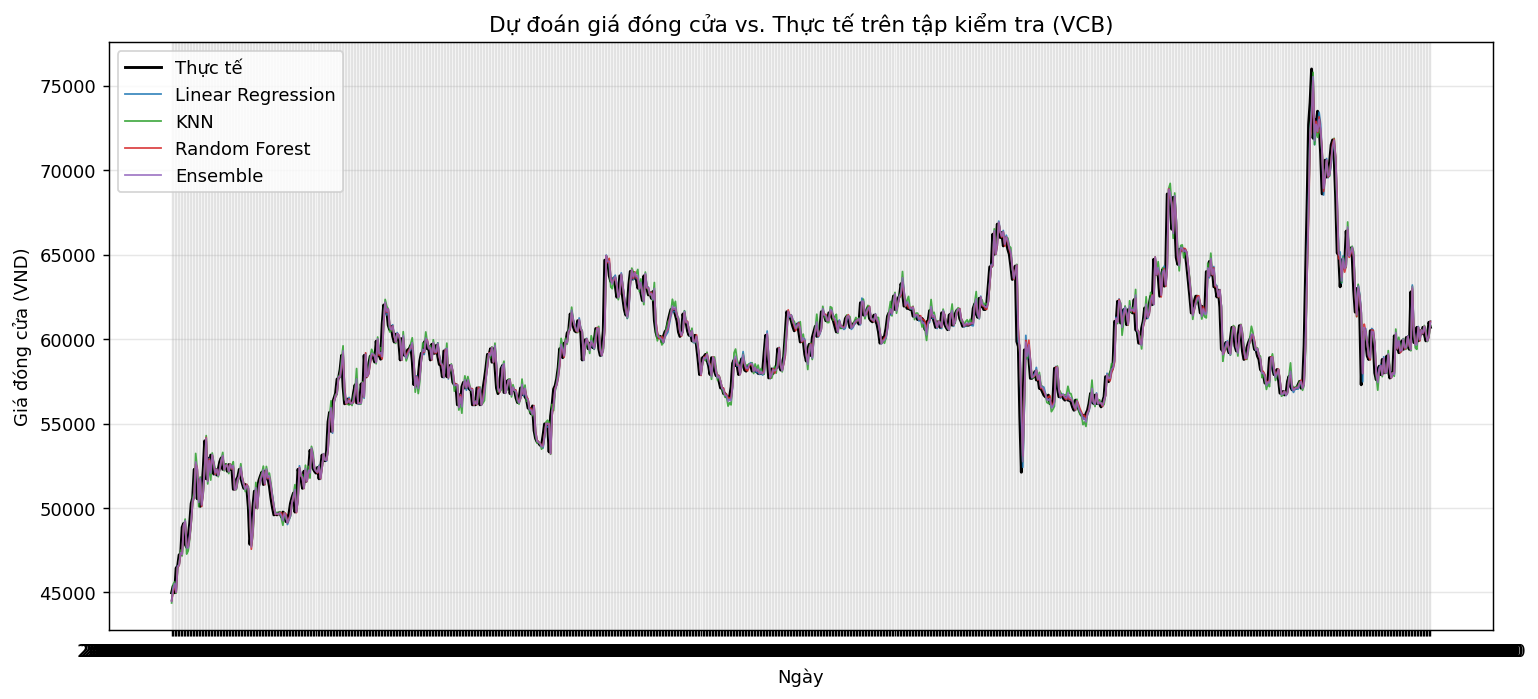

In [2]:
from IPython.display import Image, display
for name in ['price_history_daily.png',
             'returns_distribution.png',
             'correlation_heatmap.png',
             'model_comparison.png',
             'predictions_vs_actual.png']:
    print(name)
    display(Image(f'../image/{name}'))

## 5.5. Kế hoạch tiếp theo

Trong giai đoạn còn lại của project, nhóm dự định:

1. **Tinh chỉnh siêu tham số** cho KNN (`n_neighbors`, `weights`) và Random Forest (`max_depth`, `min_samples_leaf`) bằng `TimeSeriesSplit` + grid search nhỏ.
2. **Bổ sung walk-forward validation** thay vì chỉ một lần chia 80/20 để đánh giá ổn định hơn.
3. **Phân tích feature importance** của Random Forest (kỳ vọng RSI và Return_1 đứng đầu).
4. **Thử ensemble có trọng số** (weighted voting theo nghịch đảo MAE từng mô hình trên validation).
5. **Hoàn thiện Report cuối** với phần thảo luận chi tiết về Hiệu Quả Thị Trường (EMH) và hạn chế của mô hình đối với các sự kiện ngoại sinh.
6. **Chuẩn bị Presentation** (slides) trong vòng 10 phút trình bày, mỗi thành viên trình bày một phần.

---
*Kết thúc Milestone.*